
# Demand Transmission Between Sectors — Metals & Construction

This notebook implements the requested analyses on the provided dataset, focusing on two research questions:

1. **Demand Transmission Between Sectors**  
   *Question:* Do increases in new orders for fabricated metals predict shipments of primary metals?  
   - **H₀:** New orders in fabricated metals do **not** predict shipments in primary metals.  
   - **H₁:** There is a **significant positive lagged relationship**.  
   **Tests:**  
   - Granger causality between fabricated and primary metal orders  
   - Cross-correlation analysis (lead/lag relationships)  
   - OLS regression on lagged orders  
   - **ML extension:** Train an XGBoost regression model to predict shipments using lagged orders; test feature importances.

2. **Construction Demand → Metal Production**  
   *Question:* Does growth in residential construction (resconst) predict shipments in the primary metals (M3) sector?  
   - **H₀:** Construction permits/starts have **no effect** on metal shipments.  
   - **H₁:** Construction activity leads to **higher metal shipments within 1–3 months**.  
   **Tests:**  
   - Granger causality between construction activity and metal shipments  
   - Dynamic regression / distributed lag model  
   - Cross-lag correlation test  
   - **ML extension:** Use lagged construction activity and macro factors (CPI, industrial production) to forecast metal shipments; measure predictive lift.

> **Notes:**  
> - Frequency is assumed to be monthly; the code will attempt to parse and sort by the detected date column.  
> - All tests handle missing values conservatively (dropna after differencing/lagging).  
> - If XGBoost is not installed, the notebook falls back to a RandomForestRegressor (and flags this in output).


### Auto-Detected Columns

- **Date column**: `date`
- **Primary metals shipments**: `m3_VS` (M3 Primary Metals - Value of Shipments)
- **Fabricated metals new orders**: `advm3_NO` (Advance M3 - New Orders, proxy for fabricated metals)
- **Residential construction activity**: `res_APERMITS_TOTAL` (Residential Permits Total)
- **CPI**: `None` (not available in dataset)
- **Industrial Production**: `None` (not available in dataset)

> **Note**: CPI and Industrial Production are not available in this dataset. The analysis will focus on the direct relationship between fabricated orders, construction permits, and primary metals shipments.

In [1]:
import pandas as pd, numpy as np, re, warnings, sys
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

# Fixed column names and paths
CSV_PATH = "master_m3_metals_features.csv"
DATE_COL = "date"
PRIMARY_SHIP_COL = "m3_VS"  # Primary metals - Value of Shipments
FAB_ORDERS_COL = "advm3_NO"  # Advance M3 - New Orders (proxy for fabricated)
CONSTRUCT_COL = "res_APERMITS_TOTAL"  # Residential permits
CPI_COL = None  # Not available in dataset
IP_COL = None  # Not available in dataset

df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df.set_index(DATE_COL)
df = df.asfreq("MS")

def summarize_series(s, name):
    desc = s.describe()
    print(f"\nSummary for {name}:")
    print(desc.to_string())

def make_lags(s, max_lag, prefix):
    out = pd.DataFrame(index=s.index)
    for L in range(1, max_lag+1):
        out[f"{prefix}_lag{L}"] = s.shift(L)
    return out

def cross_correlation(a, b, max_lag=12):
    out = []
    a = (a - a.mean()) / (a.std() if a.std()!=0 else 1)
    b = (b - b.mean()) / (b.std() if b.std()!=0 else 1)
    for lag in range(-max_lag, max_lag+1):
        if lag < 0:
            cc = np.corrcoef(a[-lag:], b[:len(b)+lag])[0,1]
        elif lag > 0:
            cc = np.corrcoef(a[:-lag], b[lag:])[0,1]
        else:
            cc = np.corrcoef(a, b)[0,1]
        out.append({"lag": lag, "corr": cc})
    return pd.DataFrame(out)

def plot_ccf(df_ccf, title):
    plt.figure(figsize=(8,4))
    plt.stem(df_ccf["lag"], df_ccf["corr"])  # Removed deprecated parameter
    plt.axhline(0, linewidth=1, color='black', linestyle='-')
    plt.axhline(0.2, linewidth=1, color='red', linestyle='--', alpha=0.3, label='±0.2')
    plt.axhline(-0.2, linewidth=1, color='red', linestyle='--', alpha=0.3)
    plt.title(title)
    plt.xlabel("Lag (months) — positive = predictor leads")
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("XGBoost available:", HAS_XGB)
print("Dataset loaded:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
print("Index frequency:", df.index.inferred_freq)

/Users/matthewtonks/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/cg/drmdpssj7b1g61ncm5ng3gww0000gn/T/matplotlib-kubb0p_6 because there was an issue with the default path (/Users/matthewtonks/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


XGBoost available: True
Dataset loaded: (127, 1959)
Date range: 2015-01-01 00:00:00 to 2025-07-01 00:00:00
Index frequency: MS


## 1) Demand Transmission: Fabricated Metals → Primary Metals Shipments

In [2]:

# Prepare the two series
if (PRIMARY_SHIP_COL is None) or (FAB_ORDERS_COL is None):
    print("❗ Required columns not found. Skipping this section.")
else:
    y_ship = df[PRIMARY_SHIP_COL].astype(float)
    x_fab  = df[FAB_ORDERS_COL].astype(float)

    # Basic summaries
    summarize_series(y_ship, f"Primary shipments ({PRIMARY_SHIP_COL})")
    summarize_series(x_fab,  f"Fabricated new orders ({FAB_ORDERS_COL})")

    # Align and drop missing
    tmp = pd.concat([y_ship, x_fab], axis=1).dropna()
    tmp.columns = ["ship", "fab"]
    display(tmp.tail())



Summary for Primary shipments (m3_VS):
count       127.000000
mean      16475.590551
std       45827.987056
min         523.000000
25%        2903.500000
50%        6616.000000
75%       15150.500000
max      463448.000000

Summary for Fabricated new orders (advm3_NO):
count       127.000000
mean      39142.125984
std       46901.094051
min        1623.000000
25%        4915.000000
50%       20263.000000
75%       53676.000000
max      201096.000000


,ship,fab
date,,
2025-03-01,6979.0,197131.0
2025-04-01,6933.0,197143.0
2025-05-01,6877.0,198398.0
2025-06-01,6911.0,199115.0
2025-07-01,6875.0,201096.0


In [3]:

# Granger causality: does fabricated orders 'fab' help predict shipments 'ship'?
if (PRIMARY_SHIP_COL is not None) and (FAB_ORDERS_COL is not None):
    maxlag = 6
    print(f"Running Granger causality tests up to lag={maxlag}...")
    res = grangercausalitytests(tmp[["ship","fab"]].dropna(), maxlag=maxlag, verbose=False)
    rows = []
    for lag, out in res.items():
        f_p = out[0]["ssr_ftest"][1]
        rows.append({"lag": lag, "F-test pvalue (fab→ship)": f_p})
    gc_df = pd.DataFrame(rows)
    display(gc_df)
else:
    print("Skipped: columns missing.")


Running Granger causality tests up to lag=6...


,lag,F-test pvalue (fab→ship)
0,1,0.946379
1,2,0.993936
2,3,0.999078
3,4,0.999984
4,5,0.999975
5,6,0.999999


,lag,corr
3,-9,0.080132
2,-10,0.073256
5,-7,0.058991
4,-8,0.058656
1,-11,0.027480
0,-12,0.012420
7,-5,0.011508
6,-6,0.009749
8,-4,-0.002870
9,-3,-0.003791


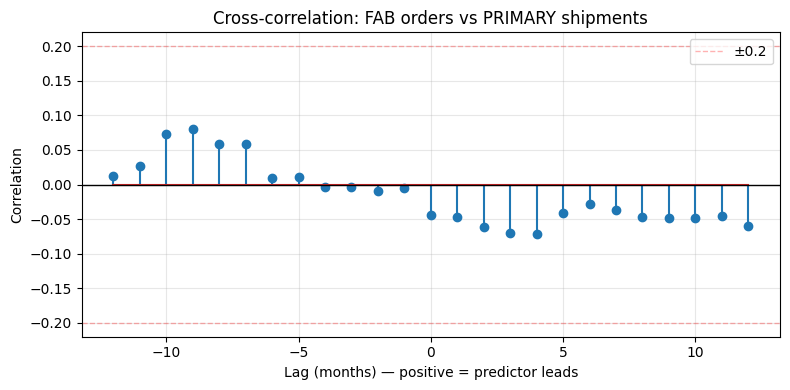

In [4]:

# Cross-correlation: positive lag = fabricated orders lead shipments
if (PRIMARY_SHIP_COL is not None) and (FAB_ORDERS_COL is not None):
    ccf_df = cross_correlation(tmp["ship"], tmp["fab"], max_lag=12)
    display(ccf_df.sort_values("corr", ascending=False).head(10))

    plot_ccf(ccf_df, "Cross-correlation: FAB orders vs PRIMARY shipments")
else:
    print("Skipped: columns missing.")


In [5]:

# OLS regression: shipments_t ~ sum_{L=1..k} fab_{t-L}
if (PRIMARY_SHIP_COL is not None) and (FAB_ORDERS_COL is not None):
    maxlag = 6
    Xlags = make_lags(tmp["fab"], maxlag, "fab")
    reg = pd.concat([tmp["ship"], Xlags], axis=1).dropna()
    y = reg["ship"]
    X = sm.add_constant(reg.drop(columns=["ship"]))
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":3})
    print(model.summary())
else:
    print("Skipped: columns missing.")


                            OLS Regression Results                            
Dep. Variable:                   ship   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.052
Method:                 Least Squares   F-statistic:                    0.1832
Date:                Wed, 29 Oct 2025   Prob (F-statistic):              0.981
Time:                        20:31:19   Log-Likelihood:                -1384.2
No. Observations:                 121   AIC:                             2782.
Df Residuals:                     114   BIC:                             2802.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.282e+04   4057.812      3.159      0.0

In [7]:
# ML extension: XGBoost (or RF fallback) using lagged FAB orders to predict shipments
if (PRIMARY_SHIP_COL is not None) and (FAB_ORDERS_COL is not None):
    maxlag = 12
    data_ml = pd.concat([tmp["ship"], make_lags(tmp["fab"], maxlag, "fab")], axis=1).dropna()
    y = data_ml["ship"].values
    X = data_ml.drop(columns=["ship"]).values
    feature_names = list(data_ml.drop(columns=["ship"]).columns)

    scaler_y = StandardScaler(with_mean=True, with_std=True)
    y_scaled = scaler_y.fit_transform(y.reshape(-1,1)).ravel()

    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    preds, trues = [], []
    importances = np.zeros(X.shape[1])

    for fold, (tr, te) in enumerate(tscv.split(X)):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y_scaled[tr], y_scaled[te]

        if HAS_XGB:
            model = XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                objective="reg:squarederror"
            )
        else:
            print("Using RandomForestRegressor fallback (xgboost not available).")
            from sklearn.ensemble import RandomForestRegressor
            model = RandomForestRegressor(n_estimators=600, max_depth=None, random_state=42)

        model.fit(Xtr, ytr)
        yhat = model.predict(Xte)
        preds.extend(yhat.tolist())
        trues.extend(yte.tolist())

        if hasattr(model, "feature_importances_"):
            importances += model.feature_importances_

    preds = np.array(preds); trues = np.array(trues)
    r2 = r2_score(trues, preds)
    mae = mean_absolute_error(trues, preds)
    rmse = mean_squared_error(trues, preds)
    print(f"Time-series CV (scaled target): R2={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")

    if importances.sum() > 0:
        importances = importances / importances.sum()
        imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
        display(imp_df.head(12))
else:
    print("Skipped: columns missing.")

Time-series CV (scaled target): R2=-2.320, MAE=0.839, RMSE=1.215


,feature,importance
0,fab_lag1,0.194337
10,fab_lag11,0.100711
2,fab_lag3,0.098961
6,fab_lag7,0.095839
7,fab_lag8,0.078416
3,fab_lag4,0.071966
9,fab_lag10,0.070927
5,fab_lag6,0.068619
1,fab_lag2,0.064993
8,fab_lag9,0.064578


## 2) Construction Demand → Metal Production (Primary Metals M3)

In [8]:

if (PRIMARY_SHIP_COL is None) or (CONSTRUCT_COL is None):
    print("❗ Required columns not found. Skipping this section.")
else:
    y_ship = df[PRIMARY_SHIP_COL].astype(float)
    x_cons = df[CONSTRUCT_COL].astype(float)

    summarize_series(y_ship, f"Primary shipments ({PRIMARY_SHIP_COL})")
    summarize_series(x_cons, f"Construction activity ({CONSTRUCT_COL})")

    tmp2 = pd.concat([y_ship, x_cons], axis=1).dropna()
    tmp2.columns = ["ship", "cons"]
    display(tmp2.tail())



Summary for Primary shipments (m3_VS):
count       127.000000
mean      16475.590551
std       45827.987056
min         523.000000
25%        2903.500000
50%        6616.000000
75%       15150.500000
max      463448.000000

Summary for Construction activity (res_APERMITS_TOTAL):
count     127.000000
mean      323.866142
std       371.398224
min       138.000000
25%       182.000000
50%       198.000000
75%       221.500000
max      1618.000000


,ship,cons
date,,
2025-03-01,6979.0,209.0
2025-04-01,6933.0,194.0
2025-05-01,6877.0,217.0
2025-06-01,6911.0,218.0
2025-07-01,6875.0,221.0


In [9]:

# Granger: does construction help predict shipments?
if (PRIMARY_SHIP_COL is not None) and (CONSTRUCT_COL is not None):
    maxlag = 6
    print(f"Running Granger causality tests up to lag={maxlag}...")
    res2 = grangercausalitytests(tmp2[["ship","cons"]].dropna(), maxlag=maxlag, verbose=False)
    rows = []
    for lag, out in res2.items():
        f_p = out[0]["ssr_ftest"][1]
        rows.append({"lag": lag, "F-test pvalue (cons→ship)": f_p})
    gc2_df = pd.DataFrame(rows)
    display(gc2_df)
else:
    print("Skipped: columns missing.")


Running Granger causality tests up to lag=6...


,lag,F-test pvalue (cons→ship)
0,1,0.141316
1,2,0.311402
2,3,0.428621
3,4,0.673642
4,5,0.751625
5,6,0.852286


,lag,corr
23,11,-0.014809
22,10,-0.026555
24,12,-0.031717
20,8,-0.047063
21,9,-0.047231
19,7,-0.052443
18,6,-0.053223
17,5,-0.057182
16,4,-0.067013
14,2,-0.082763


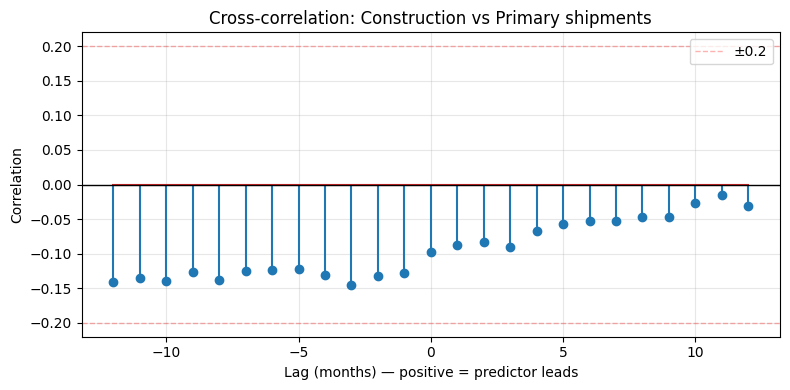

In [10]:

if (PRIMARY_SHIP_COL is not None) and (CONSTRUCT_COL is not None):
    ccf2_df = cross_correlation(tmp2["ship"], tmp2["cons"], max_lag=12)
    display(ccf2_df.sort_values("corr", ascending=False).head(10))
    plot_ccf(ccf2_df, "Cross-correlation: Construction vs Primary shipments")
else:
    print("Skipped: columns missing.")


In [11]:

# Dynamic regression / distributed lag: ship_t ~ cons_{t-1..t-6}
if (PRIMARY_SHIP_COL is not None) and (CONSTRUCT_COL is not None):
    maxlag = 6
    Xlags = make_lags(tmp2["cons"], maxlag, "cons")
    reg2 = pd.concat([tmp2["ship"], Xlags], axis=1).dropna()
    y = reg2["ship"]
    X = sm.add_constant(reg2.drop(columns=["ship"]))
    model2 = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":3})
    print(model2.summary())
else:
    print("Skipped: columns missing.")


                            OLS Regression Results                            
Dep. Variable:                   ship   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                 -0.028
Method:                 Least Squares   F-statistic:                     3.072
Date:                Wed, 29 Oct 2025   Prob (F-statistic):            0.00798
Time:                        20:32:39   Log-Likelihood:                -1382.8
No. Observations:                 121   AIC:                             2780.
Df Residuals:                     114   BIC:                             2799.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.63e+04   2820.528      5.779      0.0

In [13]:
# ML extension: Use lagged construction + macro (CPI, IP if available) to forecast shipments
if (PRIMARY_SHIP_COL is not None) and (CONSTRUCT_COL is not None):
    features = pd.DataFrame(index=df.index)
    features = pd.concat([features, make_lags(df[CONSTRUCT_COL].astype(float), 12, "cons")], axis=1)

    added = []
    if CPI_COL is not None and CPI_COL in df.columns:
        features = pd.concat([features, make_lags(df[CPI_COL].astype(float), 6, "cpi")], axis=1)
        added.append("CPI")
    if IP_COL is not None and IP_COL in df.columns:
        features = pd.concat([features, make_lags(df[IP_COL].astype(float), 6, "ip")], axis=1)
        added.append("Industrial Production")

    y = df[PRIMARY_SHIP_COL].astype(float)
    data_ml2 = pd.concat([y, features], axis=1).dropna()
    y2 = data_ml2[PRIMARY_SHIP_COL].values
    X2 = data_ml2.drop(columns=[PRIMARY_SHIP_COL]).values
    feature_names2 = list(data_ml2.drop(columns=[PRIMARY_SHIP_COL]).columns)

    scaler_y2 = StandardScaler(with_mean=True, with_std=True)
    y2_scaled = scaler_y2.fit_transform(y2.reshape(-1,1)).ravel()

    from sklearn.model_selection import TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=5)
    preds, trues = [], []
    importances = np.zeros(X2.shape[1])

    if len(data_ml2) < 30:
        print("Warning: very small sample for ML. Results may be unstable.")

    for fold, (tr, te) in enumerate(tscv.split(X2)):
        Xtr, Xte = X2[tr], X2[te]
        ytr, yte = y2_scaled[tr], y2_scaled[te]

        if HAS_XGB:
            model = XGBRegressor(
                n_estimators=700,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                objective="reg:squarederror"
            )
        else:
            print("Using RandomForestRegressor fallback (xgboost not available).")
            from sklearn.ensemble import RandomForestRegressor
            model = RandomForestRegressor(n_estimators=700, random_state=42)

        model.fit(Xtr, ytr)
        yhat = model.predict(Xte)
        preds.extend(yhat.tolist())
        trues.extend(yte.tolist())

        if hasattr(model, "feature_importances_"):
            importances += model.feature_importances_

    preds = np.array(preds); trues = np.array(trues)
    r2 = r2_score(trues, preds)
    mae = mean_absolute_error(trues, preds)
    rmse = mean_squared_error(trues, preds)
    print(f"Time-series CV (scaled target): R2={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
    if importances.sum() > 0:
        importances = importances / importances.sum()
        imp2_df = pd.DataFrame({"feature": feature_names2, "importance": importances}).sort_values("importance", ascending=False)
        display(imp2_df.head(15))
else:
    print("Skipped: columns missing.")

Time-series CV (scaled target): R2=-3.353, MAE=0.690, RMSE=1.593


,feature,importance
7,cons_lag8,0.428067
8,cons_lag9,0.130141
1,cons_lag2,0.088886
9,cons_lag10,0.065664
6,cons_lag7,0.057216
2,cons_lag3,0.056357
0,cons_lag1,0.047358
5,cons_lag6,0.035507
3,cons_lag4,0.028005
4,cons_lag5,0.025058



## Interpretation Guide (Fill using your outputs)

- **Granger (Fab→Ship):** Look for lags with small p-values (e.g., < 0.05). If any exist, we can reject H₀ for those lags.
- **Cross-correlation:** Peaks at positive lags suggest **Fab orders lead** shipments by that many months.
- **OLS (lagged):** Significant positive coefficients on lagged Fab orders support H₁. HAC SEs guard against autocorrelation.
- **ML (Fab→Ship):** If lagged Fab features rank high in importance and CV R² is reasonable, this corroborates predictive value.

- **Granger (Construction→Ship):** Significant p-values at 1–3 lags support H₁.
- **Distributed Lag:** Inspect coefficients and joint significance of 1–3 month lags.
- **Cross-lag correlation:** Positive peaks at 1–3 lags support H₁.
- **ML (Construction+Macro):** Feature importance of 1–3 month construction lags (and macro) + improved R² over a naive model = predictive lift.
